In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sd

### Load All The Raw DataSet 

In [2]:
geo = pd.read_csv("C:/Users/arpit/OneDrive/Desktop/PostNL-Scissor-Effect-Analysis/PostNL-Raw-Data/PostNL_Dim_Geography.csv")
delivery = pd.read_csv("C:/Users/arpit/OneDrive/Desktop/PostNL-Scissor-Effect-Analysis/PostNL-Raw-Data/PostNL_Fact_Deliveries.csv")
labor = pd.read_csv("C:/Users/arpit/OneDrive/Desktop/PostNL-Scissor-Effect-Analysis/PostNL-Raw-Data/PostNL_Fact_Labor.csv")

In [3]:
geo

,Depot_ID,Depot_Name,Province,Capacity_Parcels_Per_Day
0,D001,Amsterdam-West,Noord-Holland,65795
1,D002,Rotterdam-Zuid,Zuid-Holland,50860
2,D003,Utrecht-Centraal,Utrecht,126820
3,D004,Eindhoven-Hub,Noord-Brabant,104886
4,D005,Apeldoorn-Depot,Gelderland,56265
5,D006,Zwolle-Dist,Overijssel,132386
6,D007,Venlo-Gateway,Limburg,87194


In [4]:
delivery

,Parcel_ID,Date,Depot_ID,Vehicle_Type,Service_Level,Weight_kg,Distance_km,Delivery_Status,Customer_Satisfaction_Score,CO2_Emissions_kg
0,PNL00000000,2025-03-16,D003,Cargo Bike,Standard,29.47,31.5,Delivered,3,0.000
1,PNL00000001,2025-03-29,D004,Electric Van,International,10.43,16.2,Delayed,9,0.000
2,PNL00000002,2025-01-24,D004,Cargo Bike,International,11.23,19.7,Failed-Address,10,0.000
3,PNL00000003,2025-01-03,D006,Diesel Van,Next Day,18.33,39.2,Delivered,1,5.880
4,PNL00000004,2025-01-22,D007,Diesel Van,Standard,8.30,16.1,Delivered,1,2.415
...,...,...,...,...,...,...,...,...,...,...
4995,PNL00004995,2025-03-10,D001,Diesel Van,International,12.97,38.1,Delivered,1,5.715
4996,PNL00004996,2025-03-05,D003,Diesel Van,Standard,13.77,2.4,Delivered,9,0.360
4997,PNL00004997,2025-01-10,D006,Electric Van,International,15.04,39.4,Delivered,5,0.000
4998,PNL00004998,2025-02-09,D005,Diesel Van,Next Day,19.81,3.1,Delivered,7,0.465


In [5]:
labor

,Shift_ID,Date,Depot_ID,Staff_Type,Hours_Worked,Hourly_Rate_EUR
0,S00001,2025-01-09,D002,Contractor/Flex,9.436177,28
1,S00002,2025-01-23,D001,Permanent,6.447096,28
2,S00003,2025-02-16,D006,Permanent,6.352723,35
3,S00004,2025-02-05,D004,Permanent,7.108301,28
4,S00005,2025-01-31,D005,Permanent,7.267395,28
...,...,...,...,...,...,...
495,S00496,2025-03-21,D002,Permanent,6.395694,28
496,S00497,2025-02-20,D003,Contractor/Flex,9.194317,28
497,S00498,2025-01-07,D004,Contractor/Flex,8.683141,22
498,S00499,2025-02-02,D001,Permanent,7.258883,22


### Add A New Column Calculation

In [6]:
labor['Total_Labor_Cost_EUR']=round(labor['Hours_Worked']*labor['Hourly_Rate_EUR'],2)

In [7]:
labor

,Shift_ID,Date,Depot_ID,Staff_Type,Hours_Worked,Hourly_Rate_EUR,Total_Labor_Cost_EUR
0,S00001,2025-01-09,D002,Contractor/Flex,9.436177,28,264.21
1,S00002,2025-01-23,D001,Permanent,6.447096,28,180.52
2,S00003,2025-02-16,D006,Permanent,6.352723,35,222.35
3,S00004,2025-02-05,D004,Permanent,7.108301,28,199.03
4,S00005,2025-01-31,D005,Permanent,7.267395,28,203.49
...,...,...,...,...,...,...,...
495,S00496,2025-03-21,D002,Permanent,6.395694,28,179.08
496,S00497,2025-02-20,D003,Contractor/Flex,9.194317,28,257.44
497,S00498,2025-01-07,D004,Contractor/Flex,8.683141,22,191.03
498,S00499,2025-02-02,D001,Permanent,7.258883,22,159.70


### Use Agreegate & Groupby For A Better  View 

In [8]:
labor1=labor.groupby(['Date','Depot_ID']).aggregate({'Total_Labor_Cost_EUR':'sum','Hours_Worked':'sum'}).reset_index()

In [9]:
labor1

,Date,Depot_ID,Total_Labor_Cost_EUR,Hours_Worked
0,2025-01-01,D001,548.81,15.680105
1,2025-01-01,D002,158.69,7.213161
2,2025-01-01,D004,198.01,7.071699
3,2025-01-01,D007,462.99,16.535606
4,2025-01-02,D001,391.05,14.096230
...,...,...,...,...
345,2025-03-30,D001,427.11,13.612724
346,2025-03-30,D003,348.91,9.968746
347,2025-03-30,D004,243.75,6.964191
348,2025-03-31,D001,606.98,21.399003


In [10]:
delivery1=delivery.groupby(['Date','Depot_ID']).aggregate({'Parcel_ID':'count','Distance_km':'sum'}).reset_index()

In [11]:
delivery1

,Date,Depot_ID,Parcel_ID,Distance_km
0,2025-01-01,D001,10,235.5
1,2025-01-01,D002,7,122.3
2,2025-01-01,D003,2,43.0
3,2025-01-01,D004,8,208.4
4,2025-01-01,D005,6,91.5
...,...,...,...,...
625,2025-03-31,D003,9,215.9
626,2025-03-31,D004,10,278.0
627,2025-03-31,D005,12,309.4
628,2025-03-31,D006,9,181.5


In [12]:
delivery1.rename(columns={'Parcel_ID':'Volume'},inplace=True)

In [13]:
delivery1

,Date,Depot_ID,Volume,Distance_km
0,2025-01-01,D001,10,235.5
1,2025-01-01,D002,7,122.3
2,2025-01-01,D003,2,43.0
3,2025-01-01,D004,8,208.4
4,2025-01-01,D005,6,91.5
...,...,...,...,...
625,2025-03-31,D003,9,215.9
626,2025-03-31,D004,10,278.0
627,2025-03-31,D005,12,309.4
628,2025-03-31,D006,9,181.5


### Join All the Table And convert In The One Single Table 

In [14]:
cleaned_data=labor1.merge(delivery1,on=['Date','Depot_ID']).merge(geo,on=['Depot_ID'])

In [15]:
cleaned_data

,Date,Depot_ID,Total_Labor_Cost_EUR,Hours_Worked,Volume,Distance_km,Depot_Name,Province,Capacity_Parcels_Per_Day
0,2025-01-01,D001,548.81,15.680105,10,235.5,Amsterdam-West,Noord-Holland,65795
1,2025-01-01,D002,158.69,7.213161,7,122.3,Rotterdam-Zuid,Zuid-Holland,50860
2,2025-01-01,D004,198.01,7.071699,8,208.4,Eindhoven-Hub,Noord-Brabant,104886
3,2025-01-01,D007,462.99,16.535606,11,224.2,Venlo-Gateway,Limburg,87194
4,2025-01-02,D001,391.05,14.096230,11,299.8,Amsterdam-West,Noord-Holland,65795
...,...,...,...,...,...,...,...,...,...
345,2025-03-30,D001,427.11,13.612724,10,257.5,Amsterdam-West,Noord-Holland,65795
346,2025-03-30,D003,348.91,9.968746,8,217.7,Utrecht-Centraal,Utrecht,126820
347,2025-03-30,D004,243.75,6.964191,5,122.9,Eindhoven-Hub,Noord-Brabant,104886
348,2025-03-31,D001,606.98,21.399003,10,215.5,Amsterdam-West,Noord-Holland,65795


###  Calculate The Efficiency 

In [16]:
cleaned_data['Unit_Per_Cost_EUR']=round(cleaned_data['Total_Labor_Cost_EUR']/cleaned_data['Volume'],2)

In [17]:
cleaned_data

,Date,Depot_ID,Total_Labor_Cost_EUR,Hours_Worked,Volume,Distance_km,Depot_Name,Province,Capacity_Parcels_Per_Day,Unit_Per_Cost_EUR
0,2025-01-01,D001,548.81,15.680105,10,235.5,Amsterdam-West,Noord-Holland,65795,54.88
1,2025-01-01,D002,158.69,7.213161,7,122.3,Rotterdam-Zuid,Zuid-Holland,50860,22.67
2,2025-01-01,D004,198.01,7.071699,8,208.4,Eindhoven-Hub,Noord-Brabant,104886,24.75
3,2025-01-01,D007,462.99,16.535606,11,224.2,Venlo-Gateway,Limburg,87194,42.09
4,2025-01-02,D001,391.05,14.096230,11,299.8,Amsterdam-West,Noord-Holland,65795,35.55
...,...,...,...,...,...,...,...,...,...,...
345,2025-03-30,D001,427.11,13.612724,10,257.5,Amsterdam-West,Noord-Holland,65795,42.71
346,2025-03-30,D003,348.91,9.968746,8,217.7,Utrecht-Centraal,Utrecht,126820,43.61
347,2025-03-30,D004,243.75,6.964191,5,122.9,Eindhoven-Hub,Noord-Brabant,104886,48.75
348,2025-03-31,D001,606.98,21.399003,10,215.5,Amsterdam-West,Noord-Holland,65795,60.70


### Relation Between Unite_Per_Cost_EUR & Volume Of The Percels

In [18]:
Correlation=cleaned_data['Unit_Per_Cost_EUR'].corr(cleaned_data['Volume'],method='spearman')
f'Corelation between Unite_Per_Cost_EUR and Volume is {Correlation:.4f}'

'Corelation between Unite_Per_Cost_EUR and Volume is -0.5798'

### Visualization With Seaborn And See The Scissor Effect

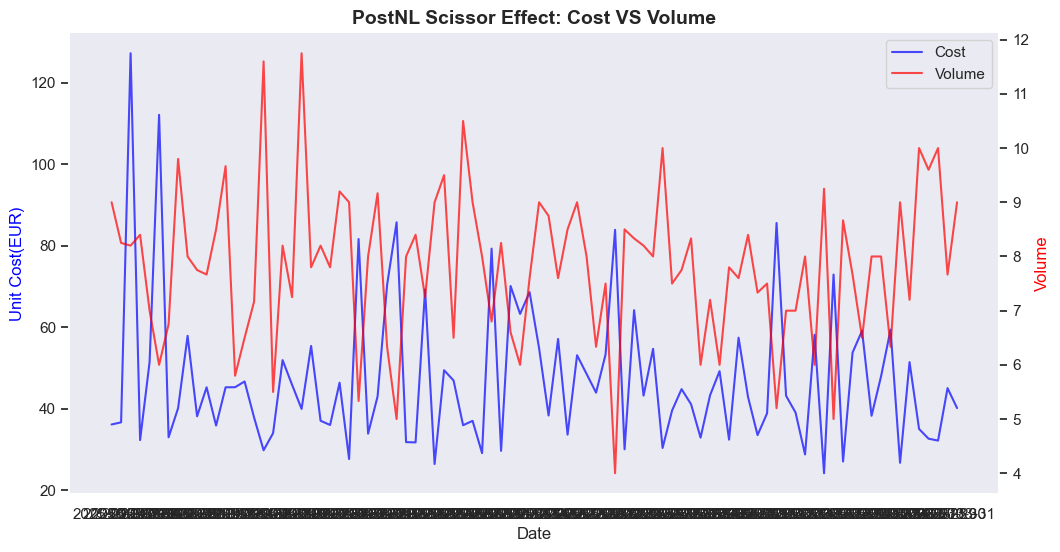

In [19]:
sd.set_theme(style='darkgrid')
fig,ax1=plt.subplots(figsize=(12,6))
sd.lineplot(data=cleaned_data, x='Date', y='Unit_Per_Cost_EUR',ax=ax1,label='Cost',color='blue',alpha=0.7,errorbar=None)
line1=ax1.set_ylabel('Unit Cost(EUR)',color='blue')
ax1.grid(False)
ax2=ax1.twinx()
sd.lineplot(data=cleaned_data, x='Date', y='Volume', label='Volume',color='red',alpha=0.7,errorbar=None)
ax2.set_ylabel('Volume',color='red')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax2.grid(False)
ax2.get_legend().remove()
plt.title('PostNL Scissor Effect: Cost VS Volume', fontsize=14,fontweight='bold');

In [20]:
cleaned_data.to_csv('C:/Users/arpit/OneDrive/Desktop/PostNL-Scissor-Effect-Analysis/PostNL_Cleaned_Analysis.csv',index=False)